In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.utils import to_categorical

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


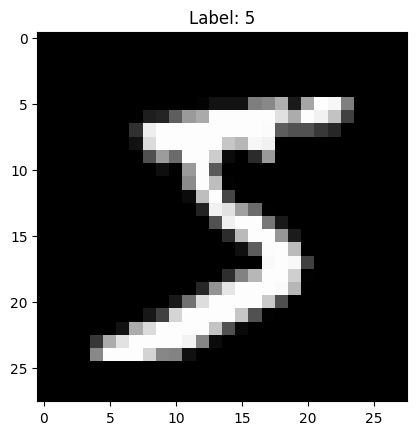

In [ ]:
# Loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display shape of data
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Display a sample image
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [ ]:
# Reshape data to fit model input (28x28 images -> 28x28x1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=128,
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 131ms/step - accuracy: 0.9110 - loss: 0.2944 - val_accuracy: 0.9818 - val_loss: 0.0578
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - accuracy: 0.9722 - loss: 0.0934 - val_accuracy: 0.9862 - val_loss: 0.0421
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.9794 - loss: 0.0682 - val_accuracy: 0.9887 - val_loss: 0.0337
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.9834 - loss: 0.0545 - val_accuracy: 0.9904 - val_loss: 0.0278
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.9865 - loss: 0.0458 - val_accuracy: 0.9906 - val_loss: 0.0284


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9906 - loss: 0.0284
Test Accuracy: 99.06%


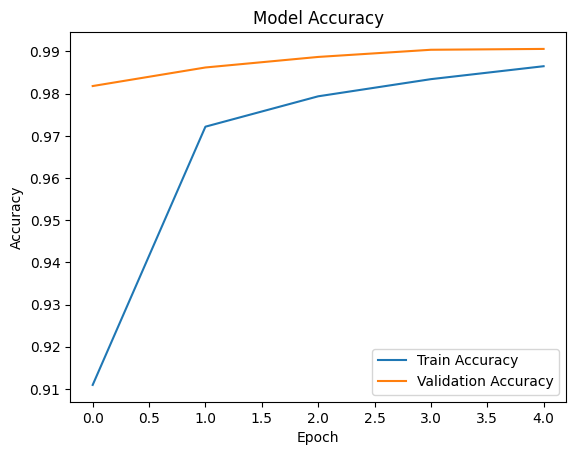

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# --- Train and Save a Simple CNN MNIST Model ---

import tensorflow as tf
from tensorflow.keras import layers, models

# 1️⃣ Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2️⃣ Normalize and reshape to match model input
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 3️⃣ Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4️⃣ Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5️⃣ Train model (3 epochs is enough for good accuracy)
history = model.fit(x_train, y_train, epochs=3,
                    validation_data=(x_test, y_test))

# 6️⃣ Save trained model
model.save('my_mnist_model.h5')
print("✅ Model trained and saved as 'my_mnist_model.h5'")

# 7️⃣ Evaluate accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"🎯 Test accuracy: {test_acc*100:.2f}%")

# 8️⃣ Confirm file exists
!ls -lh my_mnist_model.h5

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.9546 - loss: 0.1484 - val_accuracy: 0.9829 - val_loss: 0.0499
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.9851 - loss: 0.0479 - val_accuracy: 0.9869 - val_loss: 0.0402
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9890 - loss: 0.0335 - val_accuracy: 0.9881 - val_loss: 0.0367


✅ Model trained and saved as 'my_mnist_model.h5'
🎯 Test accuracy: 98.81%
-rw-r--r-- 1 root root 1.5M Apr  7 10:05 my_mnist_model.h5


Saving images.jpg to images (2).jpg


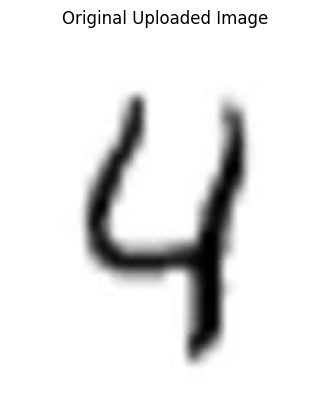

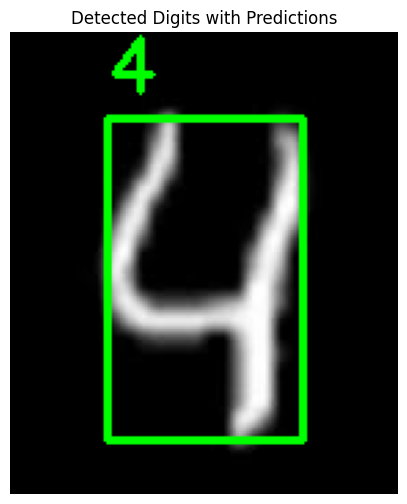

✅ Predicted Digits (left to right): 4


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Load your trained model ---
model = tf.keras.models.load_model('my_mnist_model.h5')

# --- Upload your handwritten digit image ---
uploaded = files.upload()

for fn in uploaded.keys():
    # Load grayscale image
    img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
    plt.imshow(img, cmap='gray')
    plt.title("Original Uploaded Image")
    plt.axis('off')
    plt.show()

    # Step 1: Invert if needed (white digits on black background)
    if np.mean(img) > 127:
        img = cv2.bitwise_not(img)

    # Step 2: Threshold to binary
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Step 3: Find contours (each digit)
    contours, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])  # sort left→right

    predictions = []
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)  # color copy for drawing

    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if w < 5 or h < 5:  # skip tiny noise
            continue

        # Crop the digit
        digit = img_bin[y:y+h, x:x+w]

        # Resize & pad to MNIST format
        digit = cv2.resize(digit, (18, 18))
        digit = np.pad(digit, ((5,5),(5,5)), mode='constant', constant_values=0)

        # Normalize & reshape for model
        digit = digit.astype('float32') / 255.0
        digit = digit.reshape(1, 28, 28, 1)

        # Predict digit
        prediction = model.predict(digit, verbose=0)
        predicted_digit = np.argmax(prediction)
        predictions.append((predicted_digit, (x, y, w, h)))

        # Draw bounding box and label
        cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img_color, str(predicted_digit), (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Step 4: Display result
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title("Detected Digits with Predictions")
    plt.axis('off')
    plt.show()

    # Step 5: Print all predictions
    if predictions:
        digits_only = ''.join(str(p[0]) for p in predictions)
        print("✅ Predicted Digits (left to right):", digits_only)
    else:
        print("⚠️ No digits detected. Try increasing image contrast or using a white background.")